In [1]:
import h5py
import helpers
import numpy as np
from pathlib import Path
import torch
from torch.utils import data

import os.path as osp
import os

In [2]:
torch.__version__

'2.0.1+cu118'

In [3]:
from dataloader import *

In [ ]:
# each file looks like this:
np.array(h5py.File(datadir + f, "r")['/vis/']).T[:, :, :]

In [31]:
class MyDataset(Dataset):
    def __init__(self, use_cache=False):
        self.data = torch.randn(100, 1)
        self.cached_data = []
        self.use_cache = use_cache
        
    def __getitem__(self, index):
        if not self.use_cache:
            x = self.data[index] # your slow data loading
            self.cached_data.append(x)
        else:
            x = self.cached_data[index]
        
        return x
    
    def set_use_cache(self, use_cache):
        if use_cache:
            self.cached_data = torch.stack(self.cached_data)
        else:
            self.cached_data = []
        self.use_cache = use_cache
    
    def __len__(self):
        return len(self.data)


dataset = MyDataset(use_cache=False)
loader = DataLoader(
    dataset,
    num_workers=0,
    shuffle=False
)

for data in loader:
    print(len(loader.dataset.cached_data))

loader.dataset.set_use_cache(use_cache=True)
loader.num_workers = 2
for data in loader:
    print(len(loader.dataset.cached_data))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


TypeError: '>' not supported between instances of 'NoneType' and 'int'

In [4]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import Sampler

class H5Dataset(Dataset):
    def __init__(self, cosmo_h5_file_paths, 
                 gal_h5_file_paths, 
                 use_cache=False,
                 loadcache=False,
                 root="/data101/makinen/hirax_sims/dataloader/"):
        
        self.cosmo_h5_file_paths = cosmo_h5_file_paths
        self.gal_h5_file_paths = gal_h5_file_paths
        self.use_cache = use_cache

        self.cosmo_samples = []
        self.gal_samples = []
        
        
        # gather lists of cosmo and galaxy samples
        for i,path in enumerate(cosmo_h5_file_paths):
            # each index becomes the key
            h5_file = h5py.File(path, 'r')
            self.cosmo_samples.append({'file': h5_file, 'key': i})
                        
        for path in gal_h5_file_paths:
            h5_file = h5py.File(path, 'r')
            self.gal_samples.append({'file': h5_file})
        
        
        # initialise a random index for the galaxy samples
        self.gal_indices = torch.randperm(len(gal_h5_file_paths))
        self.len_gal = len(gal_h5_file_paths)
                
        self.root = root
        
        # check to see if the root dir and x and y cache are there
        # and load 
        if loadcache:
            if osp.exists(root + "gal_cache.pt"):
                self.load_cache()

        else:
            self.gal_cache = []
            self.cosmo_cache = []
        

    # the length of the dataset is determined by the length of the cosmo map dataset
    def __len__(self):
        return len(self.cosmo_samples)

    # this method returns (x,y) = (cosmo + galaxy, cosmo) training pairs
    # here idx indexes the cosmology simulations (foregrounds will be random)
    def __getitem__(self, idx):
        
        if not self.use_cache:
            # choose the file to read in
            cosmo_sample_info = self.cosmo_samples[idx]
            cosmo_file = cosmo_sample_info['file']
            
            cosmo = torch.tensor(np.array(cosmo_file['/vis/']), dtype=torch.complex64)

            # add random foregrounds
            rand_idx = torch.randint(low=0, high=self.len_gal, size=()) #self.gal_indices[idx]
            gal_sample_info = self.gal_samples[rand_idx]

            gal_file = gal_sample_info['file']
            gal = torch.tensor(np.array(gal_file['/vis/']), dtype=torch.complex64)

            self.gal_cache.append(gal)
            self.cosmo_cache.append(cosmo)
            
            # now get x and y
            x = gal + cosmo
            y = cosmo
            
            
        else:
            # randomise foreground and cosmology combinations from cache
            rand_idx = torch.randint(low=0, high=len(self.gal_cache), size=())
            gal = self.gal_cache[rand_idx] # random index from cache
            y = self.cosmo_cache[idx] # index of cosmological simulation
            x = gal + y
            
        return x, y
    
    def set_use_cache(self, use_cache):
        if use_cache:
            self.gal_cache = torch.stack(self.gal_cache)
            self.cosmo_cache = torch.stack(self.cosmo_cache)
        else:
            self.gal_cache = []
            self.cosmo_cache = []
        self.use_cache = use_cache
        
    
    def save_cache(self):
        if not osp.exists(self.root):
            os.makedirs(self.root)
        torch.save(torch.stack(self.gal_cache), self.root + "gal_cache.pt")
        torch.save(torch.stack(self.cosmo_cache), self.root + "cosmo_cache.pt")
        
    def load_cache(self):
        self.gal_cache = torch.load(self.root + "gal_cache.pt")
        self.cosmo_cache = torch.load(self.root + "cosmo_cache.pt")
        self.use_cache = True
    

    def __del__(self):
        for sample_info in self.cosmo_samples:
            sample_info['file'].close()
        
        for sample_info in self.gal_samples:
            sample_info['file'].close()

class InfiniteSampler(Sampler):
    def __init__(self, data_source):
        self.num_samples = len(data_source)

    def __iter__(self):
        while True:
            order = torch.randperm(self.num_samples)
            for i in range(self.num_samples):
                yield order[i]

    def __len__(self):
        return 2**31

<function torch._VariableFunctionsClass.randint>

In [16]:
cosmopath = "/data101/makinen/hirax_sims/cosmo_gaussian_pb/"

f = h5py.File(cosmopath + 'cosmo_H0_60p894_vis_0.h5')

keys = list(f.keys())

keys

['index_map', 'vis']

In [17]:
f['/vis/']

<HDF5 dataset "vis": shape (48, 128, 2048), type "<c16">

In [5]:
cosmopath = "/data101/makinen/hirax_sims/cosmo_gaussian_pb/"
galpath = '/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/'

In [6]:
import os

In [7]:
cosmofiles = os.listdir(cosmopath)
galfiles = os.listdir(galpath)

In [8]:
from tqdm import tqdm
import matplotlib.pyplot as plt

100%|██████████| 25/25 [00:01<00:00, 14.32it/s]


cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
cosmo torch.Size([5, 48, 128, 2048])
gal

KeyboardInterrupt: 

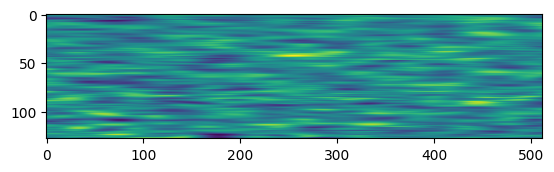

In [9]:
# Example usage
#cosmo_file_paths = ['cosmo_H0_60p894_vis_0.h5', 'cosmo_H0_69p3515_vis_54.h5']
cosmo_file_paths = [cosmopath + p for p in cosmofiles]

#gal_file_paths = ['galaxy_gsm_beta3p2_vis_31.h5',  'galaxy_md_beta3p2_vis_34.h5', 'galaxy_md_vis_45.h5', 'galaxy_md_beta3p2_vis_94.h5',  'galaxy_md_vis_94.h5']
gal_file_paths =  [galpath + p for p in galfiles]


batch_size = 5
num=25

# Create an instance of the custom dataset
my_dataset = H5Dataset(cosmo_file_paths[:num], gal_file_paths[:num], use_cache=False)

my_dataloader = DataLoader(
    my_dataset,
    num_workers=0,
    shuffle=False,
)

for data in tqdm(my_dataloader):
    pass
    #print(len(my_dataloader.dataset.gal_cache))
    

# save the cache
my_dataset.save_cache()


my_dataloader.dataset.set_use_cache(use_cache=True)
my_dataloader.num_workers = 4
my_dataloader.prefetch_factor = 1

for data in tqdm(my_dataloader):
    #print(len(my_dataloader.dataset.gal_cache))
    pass

    
    
    
    

# Use an infinite sampler to continuously sample data
my_sampler = InfiniteSampler(my_dataset)

# Create a PyTorch DataLoader
my_dataloader = DataLoader(my_dataset, batch_size=batch_size, sampler=my_sampler)

# Iterate over batches
for batch in my_dataloader:
    x,y = batch
    
    print("cosmo", y.shape)
    print("gal + cosmo", x.shape)
    
    plt.imshow(np.array(y)[0, 0, :, :512].real)

    # Your training/validation/testing logic here
    # ...

# Don't forget to close the HDF5 files when you're done
#my_dataset.close()


In [10]:
#my_dataloader.dataset.set_use_cache(use_cache=True)

my_dataset.load_cache()
my_dataloader.num_workers = 4
my_dataloader.prefetch_factor = 1

for data in tqdm(my_dataloader):
    #print(len(my_dataloader.dataset.gal_cache))
    x,y = data
    print(x.shape)
    pass

    
    
    
    

# Use an infinite sampler to continuously sample data
my_sampler = InfiniteSampler(my_dataset)

# Create a PyTorch DataLoader
my_dataloader = DataLoader(my_dataset, batch_size=batch_size, sampler=my_sampler)

# Iterate over batches
for batch in my_dataloader:
    x,y = batch
    
    print("cosmo", y.shape)
    print("gal + cosmo", x.shape)
    
    plt.imshow(np.array(x)[0, 0, :, :512].real)
    plt.show()
    
    plt.imshow(np.array(y)[0, 0, :, :512].real)
    plt.show()

  0%|          | 3/429496730 [00:01<34150:20:53,  3.49it/s] 

torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])


  0%|          | 7/429496730 [00:01<25323:28:20,  4.71it/s]

torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])


  0%|          | 10/429496730 [00:02<26041:40:03,  4.58it/s]

...

torch.Size([5, 48, 128, 2048])
torch.Size([5, 48, 128, 2048])


  0%|          | 21/429496730 [00:04<26375:16:42,  4.52it/s]

torch.Size([5, 48, 128, 2048])


  0%|          | 21/429496730 [00:05<28715:06:44,  4.15it/s]


KeyboardInterrupt: 

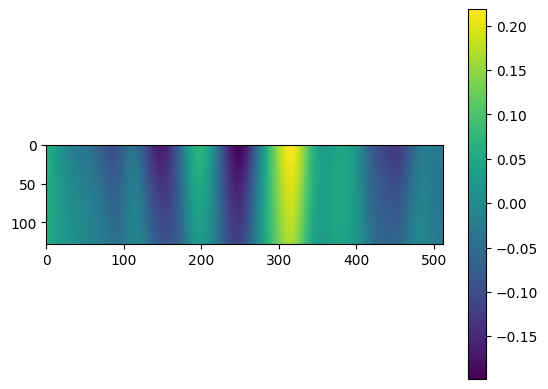

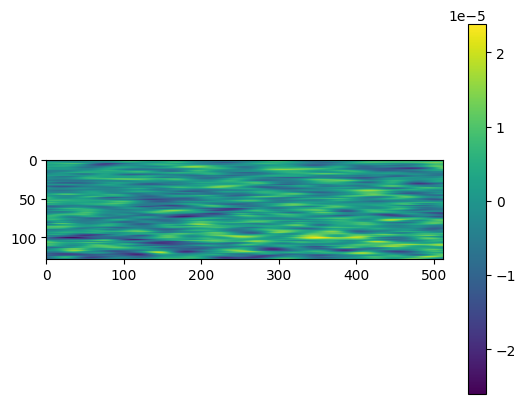

In [23]:
plt.imshow(np.array(x)[0, 0, :, :512].real)
plt.colorbar()
plt.show()

plt.imshow(np.array(y)[0, 0, :, :512].real)
plt.colorbar()
plt.show()

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
-0.024514252
0.024505172
-0.00041443668
-0.022192292


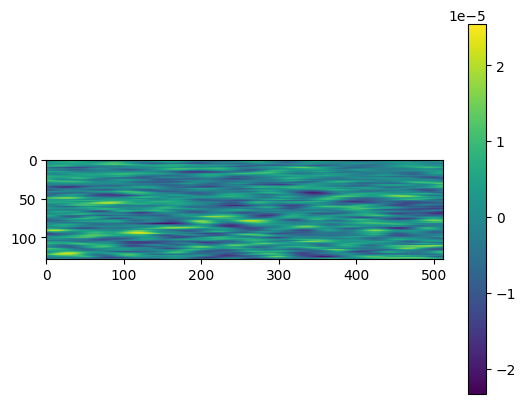

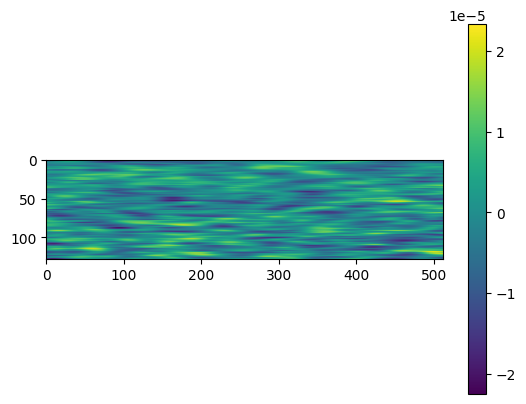

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
0.009620579
0.020367062
0.040893953
0.01752188


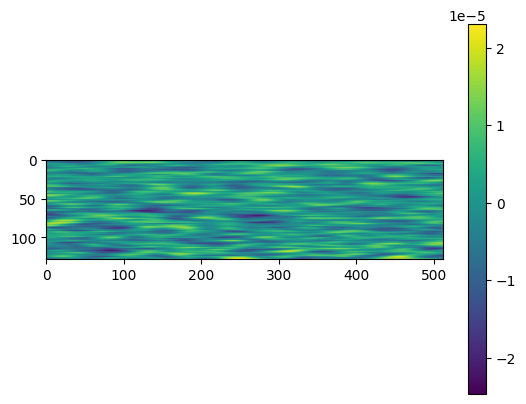

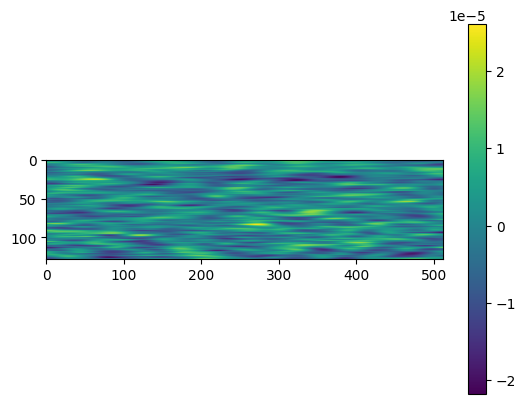

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
0.040893953
0.0024706246
0.024505172
0.009620579


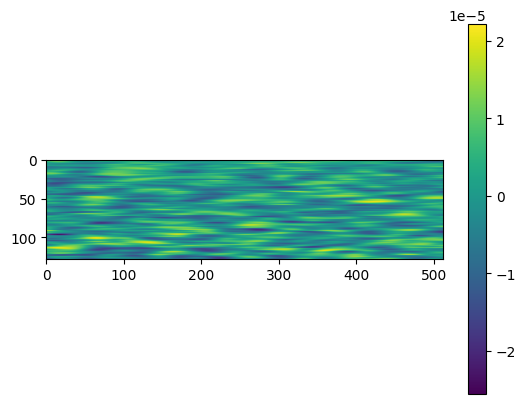

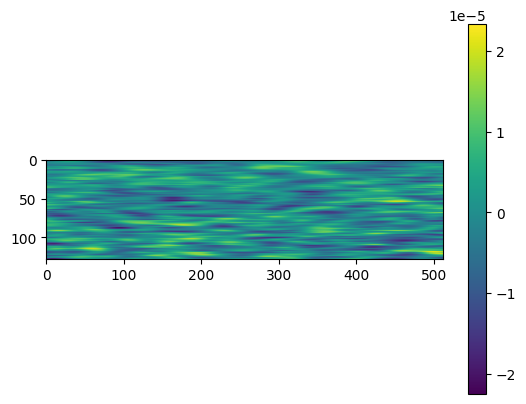

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
0.01752188
-0.024514252
-0.022192292
-0.00041443668


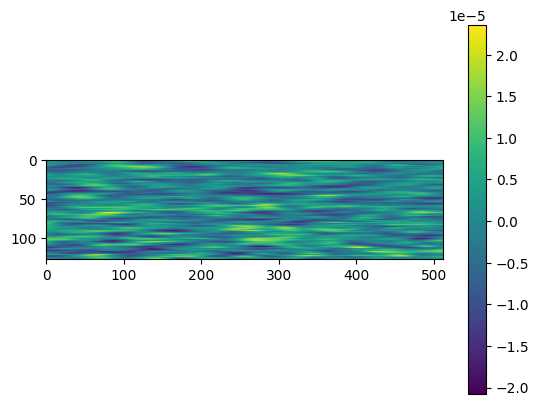

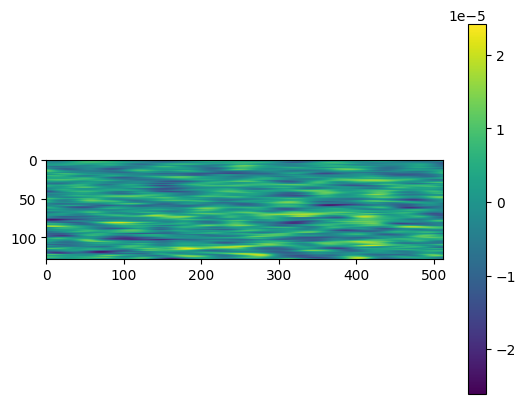

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
0.020367062
0.009620579
0.024505172
-0.00041443668


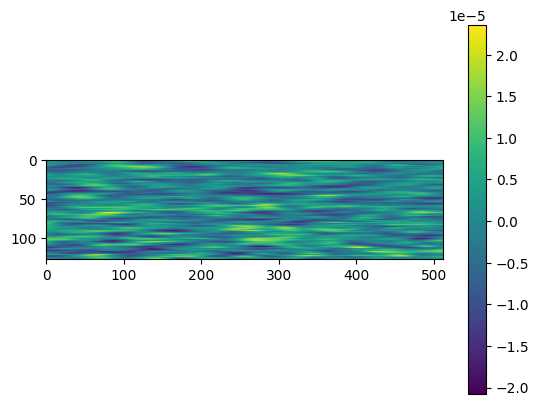

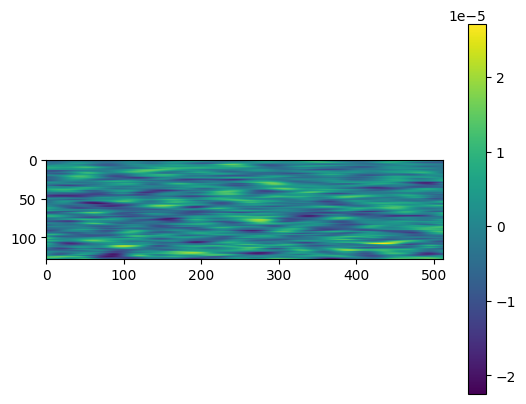

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
0.01752188
0.040893953
-0.020691391
0.0024706246


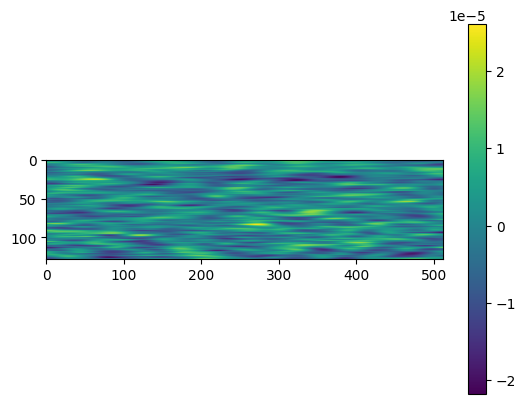

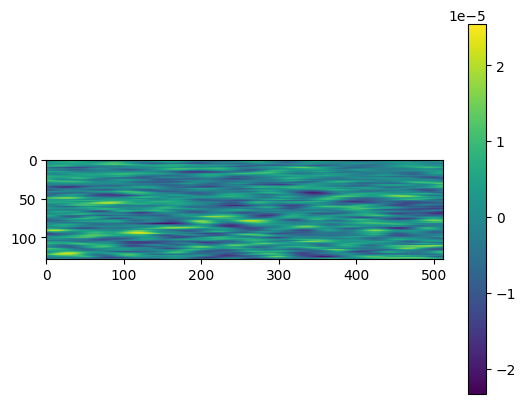

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
-0.020691391
0.040893953
0.0024706246
0.024505172


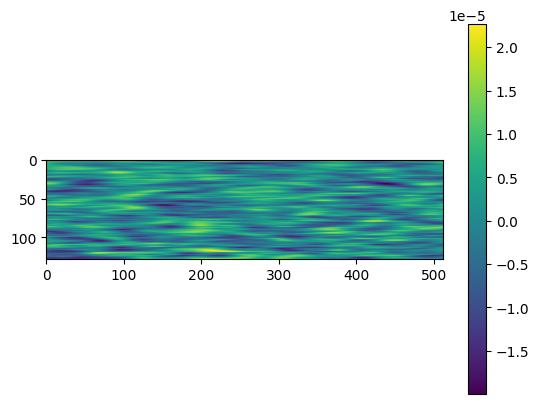

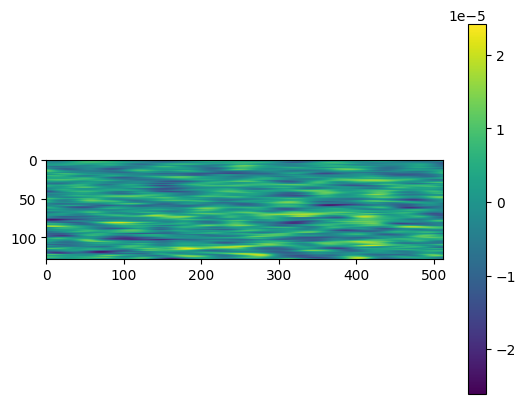

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
-0.022192292
0.01752188
-0.024514252
-0.00041443668


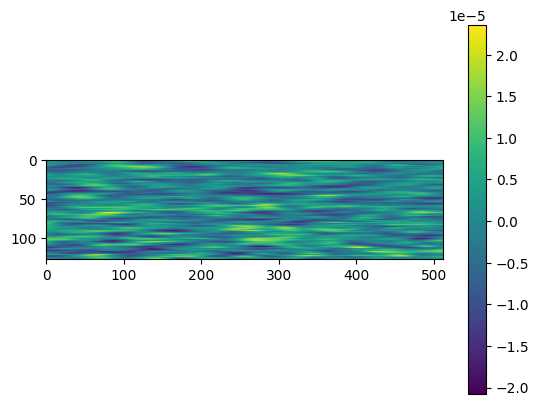

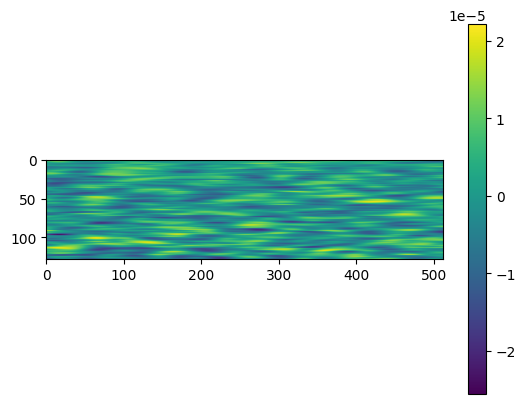

cosmo torch.Size([5, 48, 128, 2048])
gal + cosmo torch.Size([5, 48, 128, 2048])
-0.022192292


KeyboardInterrupt: 

In [36]:
# Iterate over batches
for batch in my_dataloader:
    x,y = batch
    
    print("cosmo", y.shape)
    print("gal + cosmo", x.shape)
    
    print(np.array(y)[0, 0, :, :512].real.sum())
    print(np.array(y)[1, 0, :, :512].real.sum())
    print(np.array(y)[2, 0, :, :512].real.sum())
    print(np.array(y)[3, 0, :, :512].real.sum())
    
    
    plt.imshow(np.array(y)[3, 0, :, :512].real)
    plt.colorbar()
    plt.show()
    
    plt.imshow(np.array(y)[4, 0, :, :512].real)
    plt.colorbar()
    plt.show()

In [19]:
import matplotlib.pyplot as plt

In [ ]:
outdir = "/data101/makinen/hirax_sims/"


In [4]:
from torch.utils import data

num_epochs = 50
loader_params = {'batch_size': 100, 'shuffle': True, 'num_workers': 6}

dataset = HDF5Dataset('/data101/makinen/hirax_sims/cosmo_gaussian_pb/', recursive=True, load_data=False, 
   data_cache_size=4, transform=None)

data_loader = data.DataLoader(dataset, **loader_params)

# for i in range(num_epochs):
#    for x,y in data_loader:
#       # here comes your training loop
#       pass
# view raw

AttributeError: 'Dataset' object has no attribute 'value'

In [21]:
datadir = '/data101/makinen/hirax_sims/cosmo_gaussian_pb/'
fname = 'cosmo_H0_64p277_vis_74.h5'

In [22]:
f = h5py.File(datadir + fname, "r")['/vis/'] #.T[:, :, :]


In [25]:
np.array(f).shape

(48, 128, 2048)

In [17]:
xdatadir = '/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/'
xfname = 'galaxy_md_beta3p2_vis_17.h5'

xf = h5py.File(xdatadir + xfname, "r") #['/vis/'] #.T[:, :, :]


In [19]:
xf.items()

ItemsViewHDF5(<HDF5 file "galaxy_md_beta3p2_vis_17.h5" (mode r)>)

In [20]:
with h5py.File(xdatadir + xfname) as h5_file:
            # Walk through all groups, extracting datasets
            for gname, group in h5_file.items():
                print(gname)
                print(group)
                for dname, ds in group.items():
                    print(gname, dname)

index_map
<HDF5 group "/index_map" (3 members)>
index_map baselines
index_map freq
index_map ra
vis
<HDF5 dataset "vis": shape (48, 128, 2048), type "<c16">


AttributeError: 'Dataset' object has no attribute 'items'

## convert all the h5 files to fat numpy arrays

In [28]:
import h5py, os
galaxy_path = "/data101/makinen/hirax_sims/more_baselines/galaxy_gaussian_pb/"
cosmo_path = "/data101/makinen/hirax_sims/cosmo_gaussian_pb/"

In [50]:
from tqdm import tqdm

def get_cosmo_data(datadir = cosmo_path,
                   num_train=20,
                  savedir="/data101/makinen/hirax_sims/baseline_48/"):
    
    files = os.listdir(datadir)
    print("all files", len(files))
    cosmo = []
    params = []
    files = [f for f in files if "cosmo" in f]
    print("cosmo-only files", len(files))
    
    for i,f in tqdm(enumerate(files[:num_train]), position=0):
        
        cosmo.append(np.array(h5py.File(datadir + f, "r")['/vis/']).T[:, :, :])
        p = f[9:11]
        if p == "pl":
            p = 67

        params.append(float(p)) # get H0 value
        
    if savedir is not None:
        np.save(savedir + "cosmo_vary_H0_vis", cosmo)
        np.save(savedir + "cosmo_vary_H0_params", np.array(params))
        
    return np.array(cosmo), np.array(params)


def get_galaxy_data(datadir = galaxy_path,
                   num_train=20,
                  savedir="/data101/makinen/hirax_sims/baseline_48/"):
    
    files = os.listdir(datadir)
    print("all files", len(files))
    sims = []
    
    #files = [f for f in files if "galaxy_md" in f]
    print("galaxy-only files", len(files))
    
    for i,f in tqdm(enumerate(files[:num_train]), position=0):
        #print(f)
        sims.append(np.array(h5py.File(datadir + f, "r")['/vis/']).T[:, :, :])
            
        
    if savedir:
        np.save(savedir + "galaxy_vis_all", np.array(sims))
        
    return np.array(sims)

In [31]:
savedir="/data101/makinen/hirax_sims/baseline_48/"

cosmo_vis, cosmo_params = get_cosmo_data(num_train=500, savedir=savedir)

galaxy_vis = get_galaxy_data(num_train=500, savedir=savedir)


galaxy_mask = 1024

full_cosmo = cosmo_vis[:, :galaxy_mask, :, :]
full_gal = galaxy_vis[:, :galaxy_mask, :, :]
#full_obs = np.load(outdir + "obs_gauss.npy")[:, :galaxy_mask, :, :]

full_cosmo = np.transpose(full_cosmo, (0, 3, 1, 2))
full_gal = np.transpose(full_gal, (0, 3, 1, 2))

#obs_vis = full_cosmo + full_gal

all files 900
cosmo-only files 900


1it [00:03,  3.53s/it]


KeyboardInterrupt: 

In [51]:
galaxy_vis = get_galaxy_data(num_train=500, savedir=savedir)

all files 400
galaxy-only files 400


343it [09:31,  1.67s/it]


MemoryError: Unable to allocate 192. MiB for an array with shape (48, 128, 2048) and data type complex128

In [45]:
full_gal.shape, full_cosmo.shape

((200, 48, 1024, 128), (500, 48, 1024, 128))

In [35]:
obs_vis = full_gal[:10] + full_cosmo[:10]

In [38]:
obs_vis.shape

(10, 48, 1024, 128)

In [39]:
def LoSpixels_torch(image_cube, mean_center=True):
    '''
    Convert image data cube from [Nx, Ny, Nz] to [Nz, Npix] format.

    INPUTS:
    image_cube: input data cube in image form, with shape [Nx, Ny, Nz] where Nz
    mean_center: if True, do mean centering for each frequency slice after 
    '''

    # swap axes to [Nz, Nx, Ny] for converting to visibilities:
    image_cube = torch.swapaxes(image_cube,0,1)
    image_cube = torch.swapaxes(image_cube,0,2)

    # conver to LoS pixels format [Nz, Npix]
    axes = image_cube.shape
    image_LoSpixels = torch.reshape(image_cube,(axes[0], axes[1]*axes[2]))
    
    # mean center the data:
    if mean_center==True:
        nz = image_LoSpixels.shape[0]
        for i in range(nz):
            image_LoSpixels[i] = image_LoSpixels[i] - torch.mean(image_LoSpixels[i])
    
    return image_LoSpixels

In [40]:
def PCAclean_torch(Input, N_FG=4):
    '''
    Takes input in [Nx,Ny,Nz] data cube form where Nz is number of redshift 
    (frequency) bins. N_FG is number of eigenmodes for PCA to remove
    '''
    
    # Collapse data cube to [Npix,Nz] structure:
    axes = Input.shape
    Input = LoSpixels_torch(Input, mean_center=True)
    Nz,Npix = Input.shape
    
    # Obtain frequency covariance matrix for input data
    C = torch.cov(Input)
    eigenval, eigenvec = torch.linalg.eigh(C)
    eignumb = torch.linspace(1,len(eigenval),len(eigenval))
    eigenval = torch.flip(eigenval, dims=[0]) #Put largest eigenvals first
    A = eigenvec[:,Nz-N_FG:] # Mixing matrix
    S = torch.matmul(A.T,Input) # might need to change
    
    # PCA Component Maps
    Recon_FG = torch.matmul(A,S)
    Residual = Input - Recon_FG
    Residual = torch.swapaxes(Residual,0,1) #[Nz,Npix]->[Npix,Nz]
    Residual = torch.reshape(Residual,(axes[0],axes[1],axes[2]))
    
    return Residual,eignumb,eigenval

In [36]:
from nets import *

In [48]:
pca_clean = PCAclean_torch(torch.tensor(obs_vis[0, ...].imag), N_FG=7)[0]

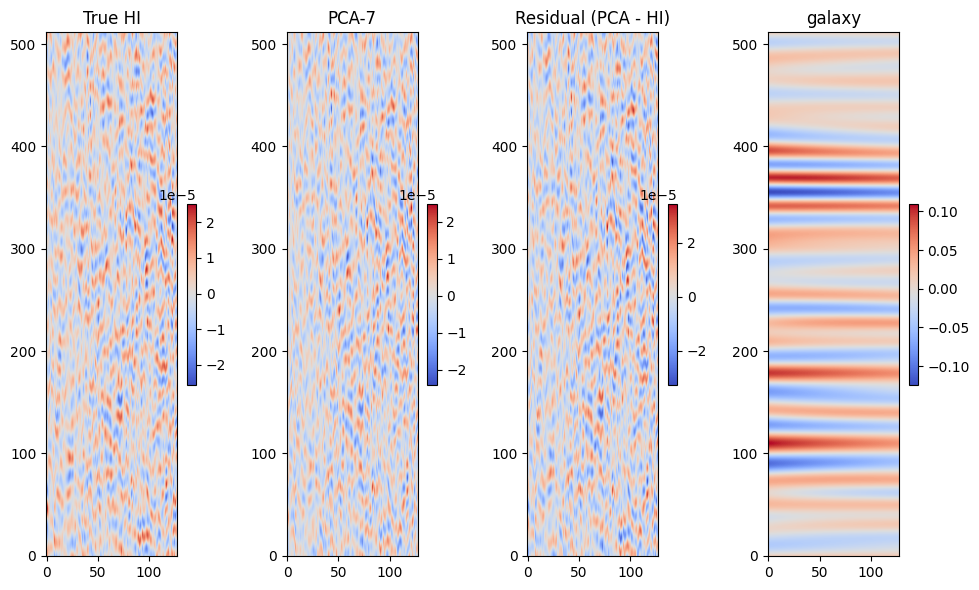

In [49]:
# do saliency plots
import matplotlib.pyplot as plt

random_sim = 0
ibase = 2
N_FG=7


plt.figure(figsize=(10,6))

#vmin = -2e-5
#vmax = 2e-5

plt.subplot(141)
pos = plt.imshow((full_cosmo[0, ibase,:512,:].real), origin = 'lower', cmap='coolwarm')
plt.colorbar(pos, fraction=0.046)
plt.title('True HI')

plt.subplot(142)
pos = plt.imshow((pca_clean.numpy()[ ibase,:512,:]).real, origin = 'lower', cmap='coolwarm')
plt.title('PCA-%d'%(N_FG))
cbar = plt.colorbar(pos, fraction=0.046)
#cbar.ax.set_ylabel(r'T [mK]', rotation=270, fontsize=18)

plt.subplot(143)
pos = plt.imshow((pca_clean.numpy()[ibase,:512,:].real - full_cosmo[0, ibase, :512,:].real),  origin = 'lower', cmap='coolwarm')
cbar = plt.colorbar(pos, fraction=0.046)
#cbar.ax.set_ylabel(r'T [mK]', rotation=270, fontsize=18)

plt.title('Residual (PCA - HI)')


plt.subplot(144)
pos = plt.imshow((full_gal[0, ibase,:512,:].real), origin = 'lower', cmap='coolwarm')
cbar = plt.colorbar(pos, fraction=0.046)
#cbar.ax.set_ylabel(r'T [mK]', rotation=270, fontsize=18)

plt.title('galaxy')
plt.tight_layout()